# [ Computer Vision ] [ CSE445 ] [ Assignment-2 ]

**Dataset Name:** IoTKITs<br>
**Source Link:** https://data.mendeley.com/datasets/x5thzmkxhy/1

## Configuration

In [1]:
!pip install -U timm ultralytics --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.2 MB/s eta 0:00:00


In [2]:
import os
import json
import copy
import random
import time
import datetime
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

partition_dir  = "/kaggle/input/notebooks/Mrpaul0007/self-supervised-learning-nb-0-partition"
ssl_pool_dir   = os.path.join(partition_dir, "ssl_pool_images")
val_images_dir = os.path.join(partition_dir, "yolo_rho20", "images", "val")
val_labels_dir = os.path.join(partition_dir, "yolo_rho20", "labels", "val")
print("Partition dataset contents:", sorted(os.listdir(partition_dir)), "\n")

working_dir = "/kaggle/working/"
os.makedirs(working_dir, exist_ok=True)

METHOD    = "DINOv3"
FAMILY    = "Self-Distillation (domain-adaptive continuation from released weights)"
ENCODER   = "timm vit_small_patch16_dinov3.lvd1689m (pretrained) + YOLOv12s CNN distillation"
BEST_YAML = "yolo12s.yaml"
ENCODER_NAME = "vit_small_patch16_dinov3.lvd1689m"

SEED         = 42
RHO          = 0.20
EMBED_DIM    = 384
OUT_DIM      = 512
IMGSZ_GLOBAL = 224
IMGSZ_LOCAL  = 96
N_GLOBAL     = 2
N_LOCAL      = 4

BATCH        = 32
EPOCHS       = 200
LR           = 5e-5
WEIGHT_DECAY = 0.04
GRAD_CLIP    = 3.0

LR_WARMUP_EPOCHS          = 1
FREEZE_LAST_LAYER_EPOCHS  = 1
TEACHER_TEMP_START        = 0.07
TEACHER_TEMP_FINAL        = 0.04
TEACHER_TEMP_WARMUP_EPOCHS = 2
MOMENTUM_TEACHER_START    = 0.996
MOMENTUM_TEACHER_END      = 1.0

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("====== Configuration ======\n")
print("Method            :", METHOD)
print("Family            :", FAMILY)
print("Encoder           :", ENCODER)
print("Distill target    :", BEST_YAML)
print("Device            :", device)
print("Seed              :", SEED)
print("Embed / out dim   :", EMBED_DIM, "/", OUT_DIM)
print("Global / local sz :", IMGSZ_GLOBAL, "/", IMGSZ_LOCAL)
print("Global / local n  :", N_GLOBAL, "/", N_LOCAL)
print("Batch size        :", BATCH)
print("Epochs            :", EPOCHS)
print("LR                :", LR)
print("Weight decay      :", WEIGHT_DECAY)
print("Grad clip norm    :", GRAD_CLIP)
print("LR warmup epochs  :", LR_WARMUP_EPOCHS)
print("Freeze-last epochs:", FREEZE_LAST_LAYER_EPOCHS)
print("Teacher temp      :", TEACHER_TEMP_START, "->", TEACHER_TEMP_FINAL, "over", TEACHER_TEMP_WARMUP_EPOCHS, "epochs")
print("Teacher momentum  :", MOMENTUM_TEACHER_START, "->", MOMENTUM_TEACHER_END)

Partition dataset contents: ['__notebook__.ipynb', '__output__.json', '__results__.html', 'custom.css', 'splits', 'ssl_pool_images', 'yolo_rho20'] 

====== Configuration ======

Method            : DINOv3
Family            : Self-Distillation (domain-adaptive continuation from released weights)
Encoder           : timm vit_small_patch16_dinov3.lvd1689m (pretrained) + YOLOv12s CNN distillation
Distill target    : yolo12s.yaml
Device            : cuda
Seed              : 42
Embed / out dim   : 384 / 512
Global / local sz : 224 / 96
Global / local n  : 2 / 4
Batch size        : 32
Epochs            : 200
LR                : 5e-05
Weight decay      : 0.04
Grad clip norm    : 3.0
LR warmup epochs  : 1
Freeze-last epochs: 1
Teacher temp      : 0.07 -> 0.04 over 2 epochs
Teacher momentum  : 0.996 -> 1.0


## Subset Verification

In [3]:
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp")

def stem_set(folder):
    names = set()
    for f in os.listdir(folder):
        if not f.lower().endswith(IMG_EXT):
            continue
        stem = f.split("__", 1)[1] if "__" in f else f
        names.add(os.path.splitext(stem)[0])
    return names

ssl_names  = stem_set(ssl_pool_dir)
val_names  = stem_set(val_images_dir)
total = len(ssl_names) + len(val_names)

print("Partition sizes (seed =", SEED, "):")
print(f"SSL pool     : {len(ssl_names):5d}  ({len(ssl_names)/total:6.2%})")
print(f"Validation   : {len(val_names):5d}  ({len(val_names)/total:6.2%})")
print(f"TOTAL |D|    : {total:5d}")

print("\nDisjointness Check:")
i_vs = val_names & ssl_names
print(f"val ∩ ssl_pool : {len(i_vs)}  -> {'PASS' if not i_vs else 'FAIL'}")
assert not i_vs, "LEAKAGE"

ssl_images = sorted(os.listdir(ssl_pool_dir))
print("\nssl_images list ready:", len(ssl_images))

Partition sizes (seed = 42 ):
SSL pool     :  2485  (88.88%)
Validation   :   311  (11.12%)
TOTAL |D|    :  2796

Disjointness Check:
val ∩ ssl_pool : 0  -> PASS

ssl_images list ready: 2485


## Model - Student, Teacher, and DINO Head

In [4]:
class DINOHead(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_dim=1024, bottleneck_dim=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, bottleneck_dim),
        )
        self.last_layer = nn.utils.parametrizations.weight_norm(
            nn.Linear(bottleneck_dim, out_dim, bias=False)
        )
        self.last_layer.parametrizations.weight.original0.data.fill_(1)
        self.last_layer.parametrizations.weight.original0.requires_grad = False

    def forward(self, x):
        x = self.mlp(x)
        x = F.normalize(x, dim=-1, p=2)
        return self.last_layer(x)


class DINOv3SSLModel(nn.Module):
    def __init__(self, encoder_name, out_dim):
        super().__init__()
        self.encoder = timm.create_model(encoder_name, pretrained=True, num_classes=0)
        self.head = DINOHead(self.encoder.num_features, out_dim=out_dim)

    def forward(self, x):
        return self.head(self.encoder(x))


def build_student_teacher():
    student = DINOv3SSLModel(ENCODER_NAME, out_dim=OUT_DIM).to(device)
    teacher = copy.deepcopy(student).to(device)
    for p in teacher.parameters():
        p.requires_grad = False
    teacher.eval()
    return student, teacher


student, teacher = build_student_teacher()

n_student = sum(p.numel() for p in student.parameters())
n_trainable = sum(p.numel() for p in student.parameters() if p.requires_grad)
n_teacher_trainable = sum(p.numel() for p in teacher.parameters() if p.requires_grad)

print(f"Student total params: {n_student/1e6:.1f}M  (trainable: {n_trainable/1e6:.1f}M)")
print(f"Teacher trainable params: {n_teacher_trainable/1e6:.1f}M  (should be 0)")
print("Encoder pretrained-init source: timm", ENCODER_NAME, "(permitted for DINOv3 per spec)")

model.safetensors:   0%|          | 0.00/86.4M [00:00<?, ?B/s]

Student total params: 23.4M  (trainable: 23.4M)
Teacher trainable params: 0.0M  (should be 0)
Encoder pretrained-init source: timm vit_small_patch16_dinov3.lvd1689m (permitted for DINOv3 per spec)


## DINO Loss + EMA Teacher Update + Schedules

In [5]:
class DINOLoss(nn.Module):
    def __init__(self, out_dim, n_global_crops, student_temp=0.1, teacher_temp=0.04, center_momentum=0.9):
        super().__init__()
        self.student_temp = student_temp
        self.teacher_temp = teacher_temp
        self.center_momentum = center_momentum
        self.n_global_crops = n_global_crops
        self.register_buffer("center", torch.zeros(1, out_dim))

    def forward(self, student_outputs, teacher_outputs):
        student_logp = [F.log_softmax(s / self.student_temp, dim=-1) for s in student_outputs]
        teacher_p = [F.softmax((t - self.center) / self.teacher_temp, dim=-1).detach() for t in teacher_outputs]

        total_loss, n_terms = 0.0, 0
        for t_idx, t_p in enumerate(teacher_p):
            for s_idx, s_logp in enumerate(student_logp):
                if s_idx == t_idx:
                    continue
                total_loss += -(t_p * s_logp).sum(dim=-1).mean()
                n_terms += 1
        total_loss /= n_terms
        self._update_center(teacher_outputs)
        return total_loss

    @torch.no_grad()
    def _update_center(self, teacher_outputs):
        batch_center = torch.cat(teacher_outputs, dim=0).mean(dim=0, keepdim=True)
        self.center = self.center * self.center_momentum + batch_center * (1 - self.center_momentum)


@torch.no_grad()
def update_teacher_ema(student, teacher, momentum):
    for s_p, t_p in zip(student.parameters(), teacher.parameters()):
        t_p.data.mul_(momentum).add_(s_p.data, alpha=1 - momentum)

def cancel_gradients_last_layer(model, freeze_this_epoch):
    if not freeze_this_epoch:
        return
    for n, p in model.named_parameters():
        if "last_layer" in n:
            p.grad = None

def momentum_schedule(step, total_steps, start, end):
    return end - (end - start) * (np.cos(np.pi * step / total_steps) + 1) / 2

def teacher_temp_schedule(epoch, warmup_epochs, start_temp, final_temp):
    if epoch >= warmup_epochs:
        return final_temp
    return start_temp + (final_temp - start_temp) * (epoch / warmup_epochs)

dino_loss_fn = DINOLoss(
    out_dim=OUT_DIM, n_global_crops=N_GLOBAL,
    teacher_temp=TEACHER_TEMP_FINAL, student_temp=0.1, center_momentum=0.9,
).to(device)

print("DINOLoss, EMA update, and schedule functions ready.")
print("Momentum schedule check (step 0/mid/last of 100):",
      round(momentum_schedule(0, 100, MOMENTUM_TEACHER_START, MOMENTUM_TEACHER_END), 4),
      round(momentum_schedule(50, 100, MOMENTUM_TEACHER_START, MOMENTUM_TEACHER_END), 4),
      round(momentum_schedule(100, 100, MOMENTUM_TEACHER_START, MOMENTUM_TEACHER_END), 4))

DINOLoss, EMA update, and schedule functions ready.
Momentum schedule check (step 0/mid/last of 100): 0.996 0.998 1.0


## Multi-Crop Augmentation + Dataset

In [6]:
from PIL import Image
from torchvision import transforms as T
from torch.utils.data import Dataset, DataLoader

MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)

class MultiCropAugmentation:
    def __init__(self):
        normalize = T.Compose([T.ToTensor(), T.Normalize(MEAN, STD)])
        flip_and_jitter = T.Compose([
            T.RandomHorizontalFlip(p=0.5),
            T.RandomApply([T.ColorJitter(0.4, 0.4, 0.2, 0.1)], p=0.8),
            T.RandomGrayscale(p=0.2),
        ])
        self.global_crop = T.Compose([
            T.RandomResizedCrop(IMGSZ_GLOBAL, scale=(0.4, 1.0), interpolation=T.InterpolationMode.BICUBIC),
            flip_and_jitter,
            T.RandomApply([T.GaussianBlur(9, sigma=(0.1, 2.0))], p=0.5),
            normalize,
        ])
        self.local_crop = T.Compose([
            T.RandomResizedCrop(IMGSZ_LOCAL, scale=(0.05, 0.4), interpolation=T.InterpolationMode.BICUBIC),
            flip_and_jitter,
            T.RandomApply([T.GaussianBlur(9, sigma=(0.1, 2.0))], p=0.5),
            normalize,
        ])

    def __call__(self, image):
        crops = [self.global_crop(image) for _ in range(N_GLOBAL)]
        crops += [self.local_crop(image) for _ in range(N_LOCAL)]
        return crops


class SSLPoolDataset(Dataset):
    def __init__(self, image_dir, file_list, augmentation):
        self.image_dir = image_dir
        self.file_list = file_list
        self.augmentation = augmentation

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.image_dir, self.file_list[idx])).convert("RGB")
        return self.augmentation(img)


def multicrop_collate(batch):
    n_views = len(batch[0])
    return [torch.stack([sample[v] for sample in batch]) for v in range(n_views)]


ssl_loader = DataLoader(
    SSLPoolDataset(ssl_pool_dir, ssl_images, MultiCropAugmentation()),
    batch_size=BATCH, shuffle=True, num_workers=2, collate_fn=multicrop_collate, drop_last=True,
)

print("SSL pool images:", len(ssl_images))
print("Batches per epoch:", len(ssl_loader))

SSL pool images: 2485
Batches per epoch: 77


## Sanity Check - Multi-Crop Demo (Single Image)

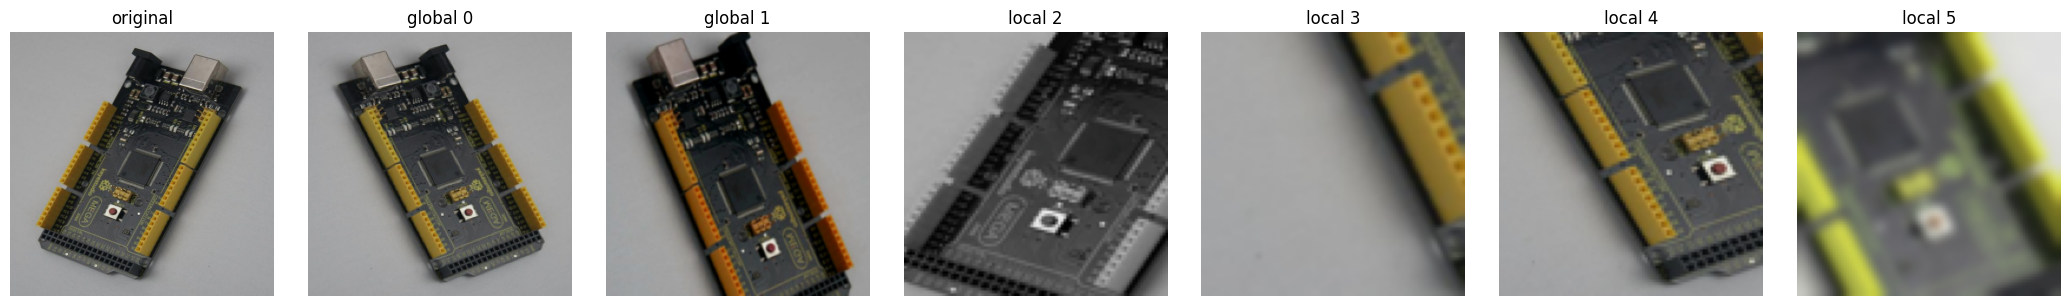

Source image: train_1000__CEAC1_jpg.rf.c0c38c7fdcd0ed55abfb04600aa99ee7.jpg
Total crops per image: 6 (2 global + 4 local)


In [7]:
import matplotlib.pyplot as plt

sample_file = ssl_images[0]
sample_img = Image.open(os.path.join(ssl_pool_dir, sample_file)).convert("RGB")

aug = MultiCropAugmentation()
crops = aug(sample_img)

def denorm(t):
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1)

fig, axes = plt.subplots(1, len(crops) + 1, figsize=(3 * (len(crops) + 1), 3))
axes[0].imshow(sample_img); axes[0].set_title("original"); axes[0].axis("off")
for i, c in enumerate(crops):
    axes[i + 1].imshow(denorm(c).permute(1, 2, 0).numpy())
    label = "global" if i < N_GLOBAL else "local"
    axes[i + 1].set_title(f"{label} {i}"); axes[i + 1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(working_dir, "dinov3_multicrop_demo.png"), dpi=150)
plt.show()

print(f"Source image: {sample_file}")
print(f"Total crops per image: {len(crops)} ({N_GLOBAL} global + {N_LOCAL} local)")

## Train DINOv3 Domain Adaptation (200 Epochs)

In [8]:
def train_one_epoch(student, teacher, loss_fn, loader, optimizer,
                     epoch, total_epochs, global_step, log_every=20):
    student.train()
    teacher.eval()

    total_steps = len(loader) * total_epochs
    warmup_steps = len(loader) * LR_WARMUP_EPOCHS
    freeze = epoch < FREEZE_LAST_LAYER_EPOCHS
    t_temp = teacher_temp_schedule(epoch, TEACHER_TEMP_WARMUP_EPOCHS, TEACHER_TEMP_START, TEACHER_TEMP_FINAL)
    loss_fn.teacher_temp = t_temp
    epoch_losses = []

    for step, views in enumerate(loader):
        lr = LR * min((global_step + 1) / warmup_steps, 1.0)
        for pg in optimizer.param_groups:
            pg["lr"] = lr

        views = [v.to(device, non_blocking=True) for v in views]
        student_outs = [student(v) for v in views]
        with torch.no_grad():
            teacher_outs = [teacher(v) for v in views[:N_GLOBAL]]

        loss = loss_fn(student_outs, teacher_outs)

        optimizer.zero_grad()
        loss.backward()
        cancel_gradients_last_layer(student, freeze)
        torch.nn.utils.clip_grad_norm_(student.parameters(), GRAD_CLIP)
        optimizer.step()

        m = momentum_schedule(global_step, total_steps, MOMENTUM_TEACHER_START, MOMENTUM_TEACHER_END)
        update_teacher_ema(student, teacher, m)

        epoch_losses.append(loss.item())
        if step % log_every == 0:
            print(f"  step {step:4d}/{len(loader)}  loss {loss.item():.4f}  lr={lr:.2e}  "
                  f"teacher_temp={t_temp:.3f}  momentum={m:.4f}")
        global_step += 1

    return float(np.mean(epoch_losses)), global_step


student, teacher = build_student_teacher()
dino_loss_fn = DINOLoss(OUT_DIM, N_GLOBAL, teacher_temp=TEACHER_TEMP_FINAL, student_temp=0.1, center_momentum=0.9).to(device)
optimizer = torch.optim.AdamW(student.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

epoch_losses = []
global_step = 0
start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    avg_loss, global_step = train_one_epoch(student, teacher, dino_loss_fn, ssl_loader, optimizer,
                                             epoch=epoch, total_epochs=EPOCHS, global_step=global_step, log_every=40)
    epoch_losses.append(avg_loss)
    elapsed_min = (time.time() - start_time) / 60
    print(f"Epoch {epoch+1} avg loss: {avg_loss:.4f}  |  elapsed: {elapsed_min:.1f} min")

    if (epoch + 1) % 20 == 0:
        torch.save(student.encoder.state_dict(), os.path.join(working_dir, f"dinov3_checkpoint_epoch{epoch+1}.pt"))
        print(f"  [checkpoint saved: epoch {epoch+1}]")

print(f"\nTraining complete. Total time: {(time.time() - start_time)/60:.1f} min")


Epoch 1/200
  step    0/77  loss 5.9138  lr=6.49e-07  teacher_temp=0.070  momentum=0.9960
  step   40/77  loss 6.2721  lr=2.66e-05  teacher_temp=0.070  momentum=0.9960
Epoch 1 avg loss: 6.2434  |  elapsed: 1.6 min

Epoch 2/200
  step    0/77  loss 6.2255  lr=5.00e-05  teacher_temp=0.055  momentum=0.9960
  step   40/77  loss 6.1949  lr=5.00e-05  teacher_temp=0.055  momentum=0.9960
Epoch 2 avg loss: 6.1931  |  elapsed: 3.3 min

Epoch 3/200
  step    0/77  loss 6.1472  lr=5.00e-05  teacher_temp=0.040  momentum=0.9960
  step   40/77  loss 6.0124  lr=5.00e-05  teacher_temp=0.040  momentum=0.9960
Epoch 3 avg loss: 6.0391  |  elapsed: 4.9 min

Epoch 4/200
  step    0/77  loss 5.9699  lr=5.00e-05  teacher_temp=0.040  momentum=0.9960
  step   40/77  loss 5.7600  lr=5.00e-05  teacher_temp=0.040  momentum=0.9960
Epoch 4 avg loss: 5.7420  |  elapsed: 6.6 min

Epoch 5/200
  step    0/77  loss 5.6409  lr=5.00e-05  teacher_temp=0.040  momentum=0.9960
  step   40/77  loss 4.7952  lr=5.00e-05  teacher

## Loss Curve

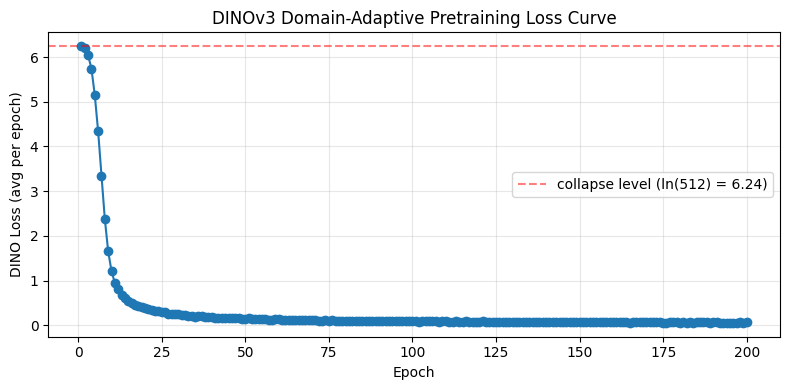

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker="o")
plt.axhline(y=np.log(OUT_DIM), color="r", linestyle="--", alpha=0.5,
            label=f"collapse level (ln({OUT_DIM}) = {np.log(OUT_DIM):.2f})")
plt.xlabel("Epoch")
plt.ylabel("DINO Loss (avg per epoch)")
plt.title("DINOv3 Domain-Adaptive Pretraining Loss Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(working_dir, "dinov3_loss_curve.png"), dpi=150)
plt.show()

## Embedding Visualization: t-SNE + Top-5 Nearest Neighbor Retrieval

Validation embeddings shape: torch.Size([311, 384])


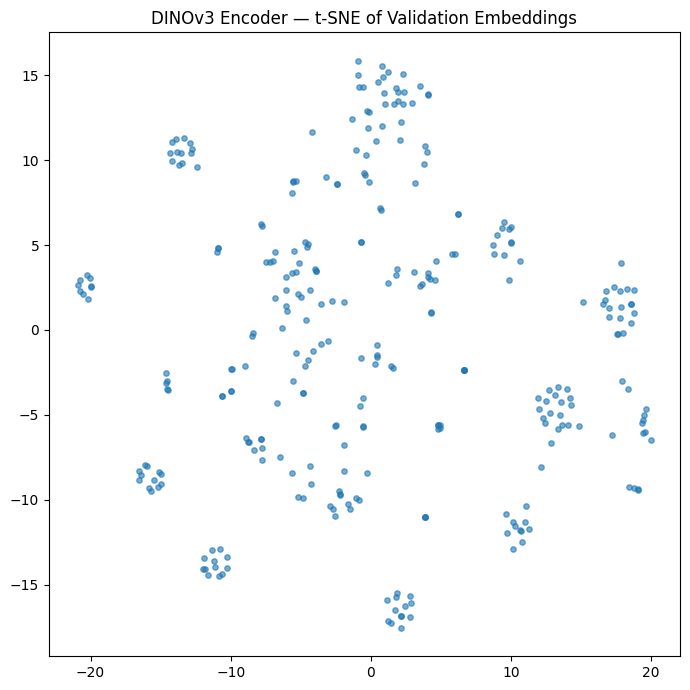

In [10]:
def get_class_from_label_file(label_path):
    if not os.path.exists(label_path):
        return -1
    with open(label_path) as f:
        line = f.readline().strip()
    return int(line.split()[0]) if line else -1

eval_transform = T.Compose([
    T.Resize((IMGSZ_GLOBAL, IMGSZ_GLOBAL), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

val_files = sorted(os.listdir(val_images_dir))
student.encoder.eval()

embeddings, class_ids, val_images_pil, filenames = [], [], [], []
with torch.no_grad():
    for fname in val_files:
        img = Image.open(os.path.join(val_images_dir, fname)).convert("RGB")
        val_images_pil.append(img.copy())
        x = eval_transform(img).unsqueeze(0).to(device)
        emb = student.encoder(x).squeeze(0).cpu()
        embeddings.append(emb)
        class_ids.append(get_class_from_label_file(os.path.join(val_labels_dir, os.path.splitext(fname)[0] + ".txt")))
        filenames.append(fname)

embeddings = torch.stack(embeddings)
class_ids = np.array(class_ids)
print("Validation embeddings shape:", embeddings.shape)

from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, init="pca")
embeddings_2d = tsne.fit_transform(embeddings.numpy())

plt.figure(figsize=(7, 7))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=15, alpha=0.6)
plt.title("DINOv3 Encoder — t-SNE of Validation Embeddings")
plt.tight_layout()
plt.savefig(os.path.join(working_dir, "dinov3_tsne.png"), dpi=150)
plt.show()

## Top-5 nearest-neighbor

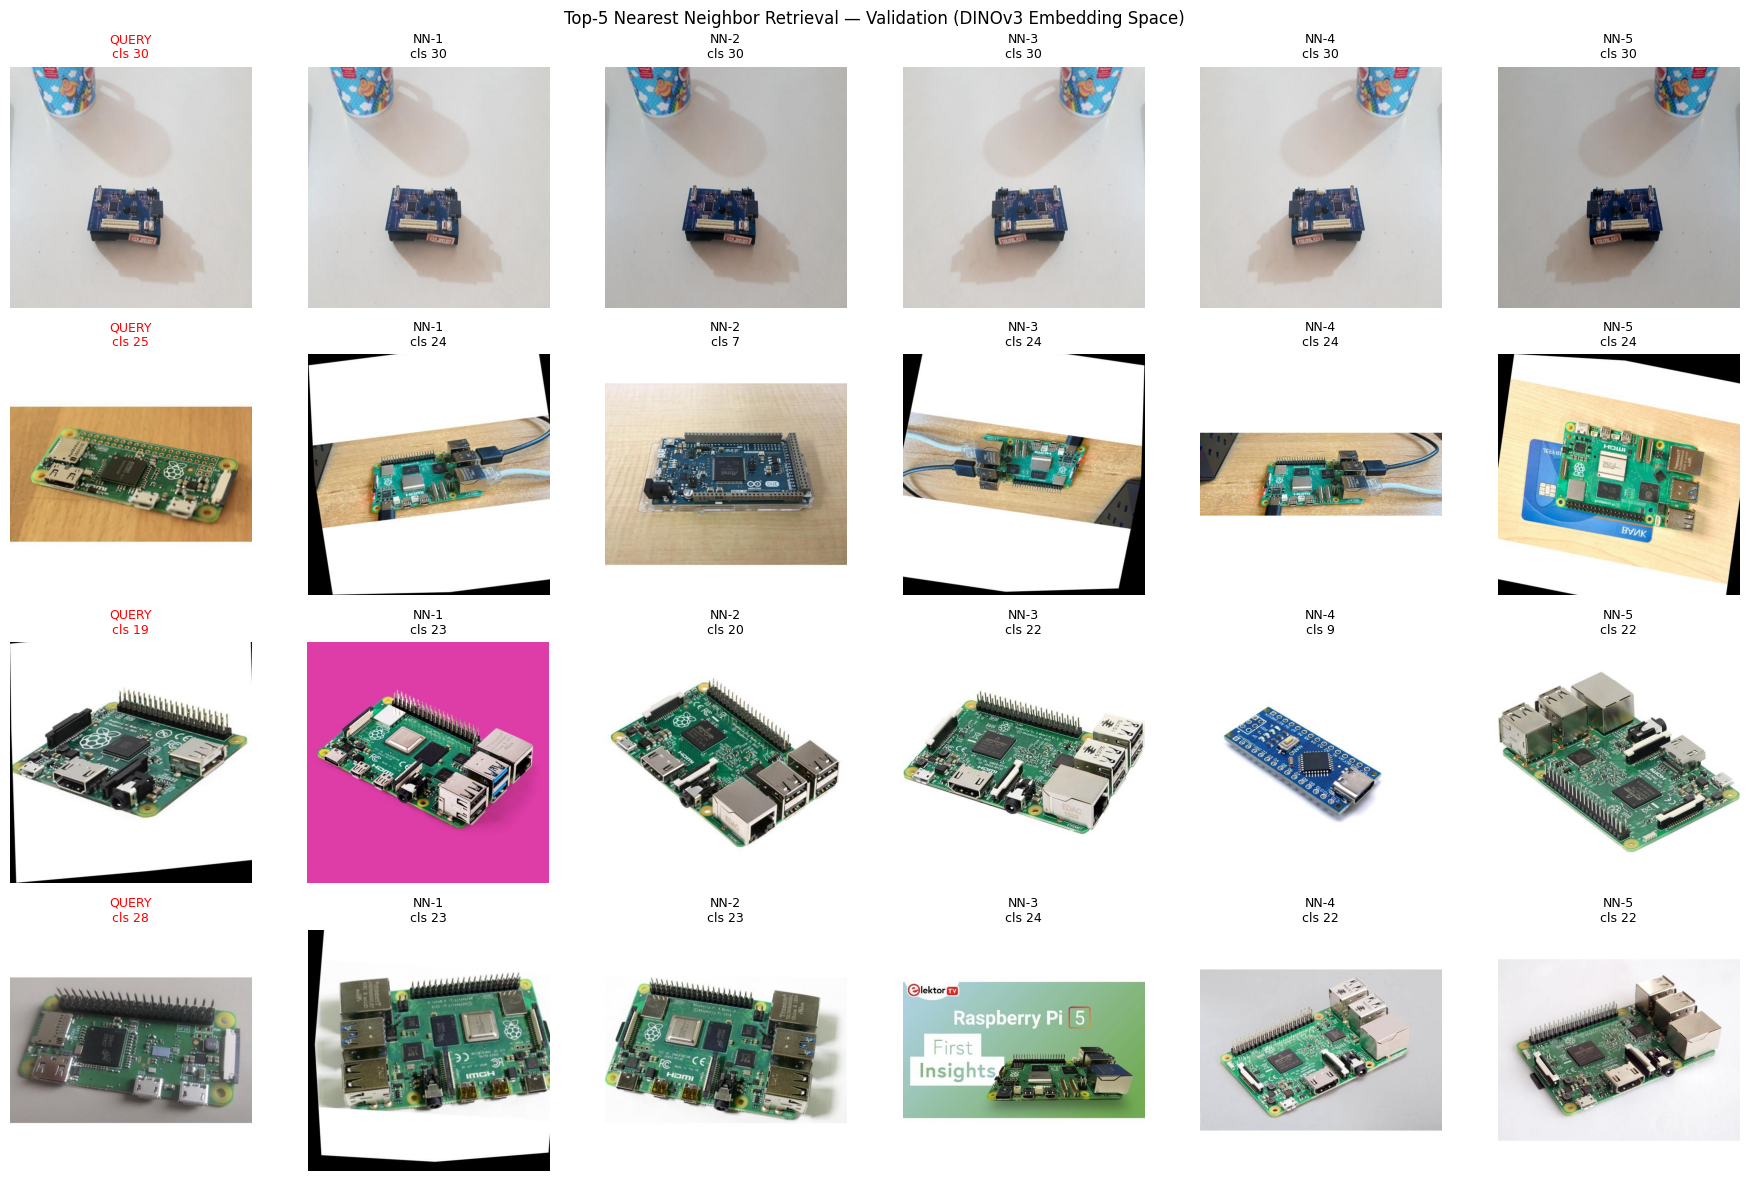

In [11]:
from sklearn.neighbors import NearestNeighbors

nn_model = NearestNeighbors(n_neighbors=6, metric="cosine")
nn_model.fit(embeddings.numpy())
rng_np = np.random.RandomState(SEED)
query_indices = rng_np.choice(len(embeddings), size=4, replace=False)

fig, axes = plt.subplots(len(query_indices), 6, figsize=(18, 3 * len(query_indices)))
for row, q_idx in enumerate(query_indices):
    _, neighbour_idx = nn_model.kneighbors(embeddings[q_idx:q_idx+1].numpy())
    for col, n_idx in enumerate(neighbour_idx[0]):
        axes[row, col].imshow(val_images_pil[n_idx])
        axes[row, col].axis("off")
        tag = f"QUERY\ncls {class_ids[n_idx]}" if col == 0 else f"NN-{col}\ncls {class_ids[n_idx]}"
        axes[row, col].set_title(tag, fontsize=9, color=("red" if col == 0 else "black"))

plt.suptitle("Top-5 Nearest Neighbor Retrieval — Validation (DINOv3 Embedding Space)")
plt.tight_layout()
plt.savefig(os.path.join(working_dir, "dinov3_retrieval_panel.png"), dpi=150)
plt.show()

## CNN Backbone Distillation - DINOv3 ViT Features → YOLOv12s Backbone

In [12]:
from ultralytics import YOLO
import timm as timm_module

full = YOLO(BEST_YAML).model
n_bb = len(full.yaml["backbone"])
print("backbone layers:", n_bb)

try:
    cnn_backbone = nn.Sequential(*list(full.model[:n_bb])).to(device)
    dummy_out = cnn_backbone(torch.randn(1, 3, IMGSZ_GLOBAL, IMGSZ_GLOBAL).to(device))
    cnn_feat_dim = dummy_out.shape[1]
    print("nn.Sequential backbone worked. Output shape:", dummy_out.shape)
    USE_TIMM = False
except Exception as e:
    print("nn.Sequential backbone FAILED:", e, "\nFalling back to timm encoder (ResNet18)")
    USE_TIMM = True
    cnn_backbone = timm_module.create_model("resnet18", pretrained=False, num_classes=0, global_pool="").to(device)
    dummy_out = cnn_backbone(torch.randn(1, 3, IMGSZ_GLOBAL, IMGSZ_GLOBAL).to(device))
    cnn_feat_dim = dummy_out.shape[1]

print("Backbone initialised from: fresh (random-init)", BEST_YAML)
print("CNN feature dim:", cnn_feat_dim)

def cnn_forward_pooled(backbone, x):
    return backbone(x).mean(dim=[2, 3])

projector = nn.Sequential(nn.Linear(cnn_feat_dim, 512), nn.ReLU(), nn.Linear(512, EMBED_DIM)).to(device)
print("Projector params:", sum(p.numel() for p in projector.parameters()))

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
backbone layers: 9
nn.Sequential backbone worked. Output shape: torch.Size([1, 512, 7, 7])
Backbone initialised from: fresh (random-init) yolo12s.yaml
CNN feature dim: 512
Projector params: 459648


## Distillation Training Loop

In [13]:
DISTILL_EPOCHS = 200

def variance_loss(features, eps=1e-4):
    return torch.mean(F.relu(1.0 - torch.sqrt(features.var(dim=0) + eps)))

def covariance_loss(features):
    B, D = features.shape
    features = features - features.mean(dim=0)
    cov = (features.T @ features) / (B - 1)
    return ((cov - torch.diag(torch.diagonal(cov))) ** 2).sum() / D

teacher.eval()
for p in teacher.parameters():
    p.requires_grad = False

def cosine_distill_loss(cnn_feat, vit_feat):
    return -(F.normalize(cnn_feat, dim=-1) * F.normalize(vit_feat, dim=-1)).sum(dim=-1).mean()

distill_transform = T.Compose([
    T.Resize((IMGSZ_GLOBAL, IMGSZ_GLOBAL), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(), T.Normalize(MEAN, STD),
])
distill_loader = DataLoader(
    SSLPoolDataset(ssl_pool_dir, ssl_images, lambda img: distill_transform(img)),
    batch_size=BATCH, shuffle=True, num_workers=2, drop_last=True,
)

distill_optimizer = torch.optim.AdamW(list(cnn_backbone.parameters()) + list(projector.parameters()), lr=1e-4, weight_decay=0.05)
distill_total_steps = DISTILL_EPOCHS * len(distill_loader)
distill_scheduler = torch.optim.lr_scheduler.LambdaLR(
    distill_optimizer, lambda step: 0.5 * (1 + np.cos(np.pi * step / max(1, distill_total_steps)))
)
distill_scaler = torch.amp.GradScaler("cuda", enabled=True)

VARIANCE_WEIGHT, COVARIANCE_WEIGHT = 5.0, 1.0
distill_losses = []
print(f"Distilling for {DISTILL_EPOCHS} epochs, {len(distill_loader)} batches/epoch")
start_time = time.time()

for epoch in range(DISTILL_EPOCHS):
    cnn_backbone.train(); projector.train()
    running_loss = 0.0
    for images in distill_loader:
        images = images.to(device, non_blocking=True)
        distill_optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            with torch.no_grad():
                vit_feat = teacher.encoder(images)
            cnn_projected = projector(cnn_forward_pooled(cnn_backbone, images))
            cnn_normed = F.normalize(cnn_projected, dim=-1)
            sim_loss = cosine_distill_loss(cnn_projected, vit_feat)
            var_loss = variance_loss(cnn_normed)
            cov_loss = covariance_loss(cnn_normed)
            loss = sim_loss + VARIANCE_WEIGHT * var_loss + COVARIANCE_WEIGHT * cov_loss
        distill_scaler.scale(loss).backward()
        distill_scaler.step(distill_optimizer); distill_scaler.update(); distill_scheduler.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(distill_loader)
    distill_losses.append(avg_loss)
    print(f"Distill epoch {epoch+1:3d}/{DISTILL_EPOCHS}  loss: {avg_loss:.4f}  sim: {sim_loss.item():.4f}  "
          f"var: {var_loss.item():.4f}  cov: {cov_loss.item():.4f}  elapsed: {(time.time()-start_time)/60:.1f} min")

print("\nDistillation complete.")

Distilling for 200 epochs, 77 batches/epoch


/tmp/ipykernel_22/3338886837.py:56: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  distill_scaler.step(distill_optimizer); distill_scaler.update(); distill_scheduler.step()


Distill epoch   1/200  loss: 4.4994  sim: -0.3941  var: 0.9570  cov: 0.0003  elapsed: 0.2 min
Distill epoch   2/200  loss: 4.3214  sim: -0.5119  var: 0.9544  cov: 0.0002  elapsed: 0.4 min
Distill epoch   3/200  loss: 4.2389  sim: -0.5154  var: 0.9536  cov: 0.0002  elapsed: 0.7 min
Distill epoch   4/200  loss: 4.1686  sim: -0.6785  var: 0.9523  cov: 0.0002  elapsed: 0.9 min
Distill epoch   5/200  loss: 4.1069  sim: -0.6538  var: 0.9523  cov: 0.0002  elapsed: 1.1 min
Distill epoch   6/200  loss: 4.0562  sim: -0.6368  var: 0.9516  cov: 0.0002  elapsed: 1.3 min
Distill epoch   7/200  loss: 4.0159  sim: -0.7546  var: 0.9511  cov: 0.0002  elapsed: 1.5 min
Distill epoch   8/200  loss: 3.9889  sim: -0.7567  var: 0.9510  cov: 0.0002  elapsed: 1.7 min
Distill epoch   9/200  loss: 3.9640  sim: -0.7899  var: 0.9506  cov: 0.0001  elapsed: 1.9 min
Distill epoch  10/200  loss: 3.9419  sim: -0.8252  var: 0.9508  cov: 0.0002  elapsed: 2.1 min
Distill epoch  11/200  loss: 3.9259  sim: -0.8279  var: 0.95

## Distillation Sanity Check - Collapse Verification

In [14]:
cnn_backbone.eval(); projector.eval()
sample_images = next(iter(distill_loader))[:16].to(device)
with torch.no_grad():
    sample_projected = F.normalize(projector(cnn_forward_pooled(cnn_backbone, sample_images)), dim=-1)
sim_matrix = sample_projected @ sample_projected.T
off_diagonal = sim_matrix[~torch.eye(16, dtype=torch.bool, device=device)]
print("Mean pairwise similarity between DIFFERENT images' CNN features:", off_diagonal.mean().item())

Mean pairwise similarity between DIFFERENT images' CNN features: 0.09661365300416946


## Save Best Checkpoint

In [15]:
ckpt_path = os.path.join(working_dir, "dinov3_backbone.pt")
torch.save(cnn_backbone.state_dict(), ckpt_path)
print("DINOv3 backbone saved:", ckpt_path)

reload_check = nn.Sequential(*list(YOLO(BEST_YAML).model.model[:n_bb]))
missing, unexpected = reload_check.load_state_dict(torch.load(ckpt_path, map_location="cpu"), strict=False)
print("Reload check — missing:", len(missing), "unexpected:", len(unexpected))
print("Reload check passed." if not missing and not unexpected else "Reload check FAILED.")

DINOv3 backbone saved: /kaggle/working/dinov3_backbone.pt
Reload check — missing: 0 unexpected: 0
Reload check passed.
